# Gün 13 Demo - Anlam Uzayı ve Kosinüs Benzerliği

Raporda embedding'in "anlamı koruyan bir vektör temsili" olduğunu yazdım. Bu demoda
onu somutlaştırıyorum.

Burada gerçek bir embedding modeli **kullanmıyorum**. Bunun sebebi şu: gerçek modelin
ürettiği 768 boyutlu vektörlere baktığımda sadece anlamsız sayılar görürüm, boyutların
neye karşılık geldiğini anlayamam. Onun yerine boyutlarının anlamını **kendim
atadığım** küçük bir uzay kuruyorum. Böylece "benzerlik" hesabının içeride ne yaptığını
gerçekten görebiliyorum.

Gerçek embedding'leri gün 15'te bir modelden alacağım; hesaplama mantığı birebir
aynı olacak, sadece boyut sayısı ve vektörlerin kaynağı değişecek.

Ayrıca burada yazacağım kosinüs benzerliği fonksiyonu, görevlendirmenin uygulama
bölümünde istenen fonksiyonun ta kendisi.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print("torch:", torch.__version__)
print("numpy:", np.__version__)

torch: 2.13.0+cu130
numpy: 2.5.1


## 1. Adım - Anlam uzayını elle kuruyorum

6 boyutlu bir uzay tanımlıyorum ve her boyuta bir anlam veriyorum:

| Boyut | Anlamı |
|---|---|
| 0 | insanlık |
| 1 | soyluluk |
| 2 | dişilik |
| 3 | hayvansallık |
| 4 | nesnellik |
| 5 | yenilebilirlik |

Sonra 8 kelimeyi bu boyutlarda 0 ile 1 arasında puanlıyorum. Mesela "kral" insan
(1.0), soylu (0.9), dişi değil (0.0).

Gerçek bir embedding modelinde de olan tam olarak bu; tek fark boyutların anlamını
kimsenin atamaması, modelin eğitim sırasında kendi kendine bulması. O yüzden gerçek
boyutlara bakınca "bu boyut soyluluk" diyemiyoruz.

In [2]:
boyut_adlari = ["insanlık", "soyluluk", "dişilik", "hayvansallık", "nesnellik", "yenilebilirlik"]

kelimeler = ["kral", "kraliçe", "adam", "kadın", "köpek", "kedi", "masa", "elma"]

E = torch.tensor([
    #  insan  soylu  dişi   hayvan nesne  yenilebilir
    [   1.00,  0.90,  0.00,  0.10,  0.00,  0.00],   # kral
    [   1.00,  0.90,  0.90,  0.10,  0.00,  0.00],   # kraliçe
    [   1.00,  0.10,  0.00,  0.10,  0.00,  0.00],   # adam
    [   1.00,  0.10,  0.90,  0.10,  0.00,  0.00],   # kadın
    [   0.10,  0.00,  0.00,  1.00,  0.00,  0.00],   # köpek
    [   0.10,  0.00,  0.00,  0.95,  0.00,  0.00],   # kedi
    [   0.00,  0.00,  0.00,  0.00,  1.00,  0.00],   # masa
    [   0.00,  0.00,  0.00,  0.00,  0.60,  1.00],   # elma
])

print("embedding matrisi shape:", tuple(E.shape))
print("  ->", E.shape[0], "kelime,", E.shape[1], "boyut")
print()
print(f"{'':10}" + "".join(f"{b:>15}" for b in boyut_adlari))
for i, k in enumerate(kelimeler):
    print(f"{k:10}" + "".join(f"{v:>15.2f}" for v in E[i].tolist()))

embedding matrisi shape: (8, 6)
  -> 8 kelime, 6 boyut

                 insanlık       soyluluk        dişilik   hayvansallık      nesnellik yenilebilirlik
kral                 1.00           0.90           0.00           0.10           0.00           0.00
kraliçe              1.00           0.90           0.90           0.10           0.00           0.00
adam                 1.00           0.10           0.00           0.10           0.00           0.00
kadın                1.00           0.10           0.90           0.10           0.00           0.00
köpek                0.10           0.00           0.00           1.00           0.00           0.00
kedi                 0.10           0.00           0.00           0.95           0.00           0.00
masa                 0.00           0.00           0.00           0.00           1.00           0.00
elma                 0.00           0.00           0.00           0.00           0.60           1.00


## 2. Adım - Kosinüs benzerliğini elle yazıyorum

Formül şu:

```
benzerlik(a, b) = (a · b) / (|a| * |b|)
```

Üç parçası var:

- **`a · b`** (iç çarpım): iki vektörün karşılıklı elemanlarını çarpıp topluyor.
  Aynı boyutlarda yüksek değerleri olan vektörlerde büyük çıkıyor.
- **`|a|`** (norm): vektörün uzunluğu, yani `sqrt(a1² + a2² + ...)`.
- **Bölme:** iç çarpımı uzunluklara bölmek, sonucu **yalnızca yöne** bağlı hale
  getiriyor. Uzunluk etkisi ortadan kalkıyor.

Sonuç -1 ile 1 arasında çıkıyor: 1 aynı yön, 0 alakasız (dik), -1 zıt yön. Metin
embedding'lerinde değerler genelde 0 ile 1 arasında kalıyor.

Fonksiyonu saf numpy ile yazıyorum, çünkü görevlendirmenin uygulama bölümünde
istenen tam olarak bu. Sonra PyTorch'un hazır fonksiyonuyla karşılaştırıp doğru
yazdığımı kontrol ediyorum.

In [3]:
def kosinus_benzerligi(a, b):
    """İki vektör arasındaki kosinüs benzerliği. Saf numpy."""
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    ic_carpim = np.dot(a, b)          # a · b
    norm_a = np.sqrt(np.sum(a ** 2))  # |a|
    norm_b = np.sqrt(np.sum(b ** 2))  # |b|

    if norm_a == 0 or norm_b == 0:    # sıfır vektörde bölme hatası olmasın
        return 0.0

    return float(ic_carpim / (norm_a * norm_b))


# kendi fonksiyonum vs PyTorch'un hazır fonksiyonu
a, b = E[0], E[1]   # kral, kraliçe

benim = kosinus_benzerligi(a.numpy(), b.numpy())
pytorch = torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

print(f"benim fonksiyonum : {benim:.6f}")
print(f"pytorch           : {pytorch:.6f}")
print(f"aynı mı           : {abs(benim - pytorch) < 1e-6}")

benim fonksiyonum : 0.831875
pytorch           : 0.831874
aynı mı           : True


İkisi aynı çıktı, fonksiyon doğru.

## 3. Adım - Bütün kelimeleri birbiriyle karşılaştırıyorum

Şimdi 8 kelimenin hepsini birbiriyle karşılaştırıp bir benzerlik matrisi çıkarıyorum.
Beklentim: kral-kraliçe yüksek, köpek-kedi yüksek, kral-masa düşük.

In [4]:
n_kelime = len(kelimeler)
benzerlik = np.zeros((n_kelime, n_kelime))

for i in range(n_kelime):
    for j in range(n_kelime):
        benzerlik[i, j] = kosinus_benzerligi(E[i].numpy(), E[j].numpy())

# tabloyu yazdır
print(f"{'':10}" + "".join(f"{k:>9}" for k in kelimeler))
for i, k in enumerate(kelimeler):
    print(f"{k:10}" + "".join(f"{benzerlik[i, j]:9.2f}" for j in range(n_kelime)))

               kral  kraliçe     adam    kadın    köpek     kedi     masa     elma
kral           1.00     0.83     0.81     0.60     0.15     0.15     0.00     0.00
kraliçe        0.83     1.00     0.67     0.87     0.12     0.13     0.00     0.00
adam           0.81     0.67     1.00     0.75     0.20     0.20     0.00     0.00
kadın          0.60     0.87     0.75     1.00     0.15     0.15     0.00     0.00
köpek          0.15     0.12     0.20     0.15     1.00     1.00     0.00     0.00
kedi           0.15     0.13     0.20     0.15     1.00     1.00     0.00     0.00
masa           0.00     0.00     0.00     0.00     0.00     0.00     1.00     0.51
elma           0.00     0.00     0.00     0.00     0.00     0.00     0.51     1.00


Sayılara bakmak zor, bir de renkli görelim.

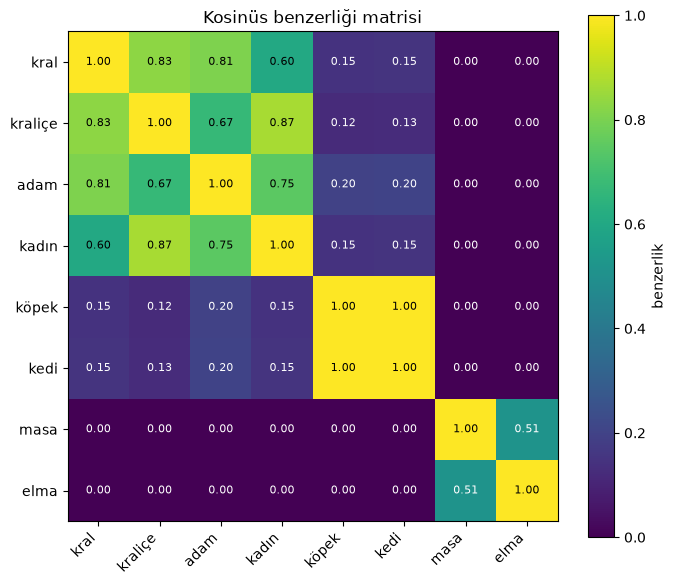

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(benzerlik, cmap="viridis", vmin=0, vmax=1)

ax.set_xticks(range(n_kelime), kelimeler, rotation=45, ha="right")
ax.set_yticks(range(n_kelime), kelimeler)

for i in range(n_kelime):
    for j in range(n_kelime):
        renk = "white" if benzerlik[i, j] < 0.6 else "black"
        ax.text(j, i, f"{benzerlik[i, j]:.2f}", ha="center", va="center",
                color=renk, fontsize=8)

ax.set_title("Kosinüs benzerliği matrisi")
plt.colorbar(im, label="benzerlik")
plt.tight_layout()
plt.show()

Matris beklediğim gibi çıktı. Köşegen hep 1.00 (her kelime kendine tam benziyor) ve
matris simetrik. Anlamlı gruplar da net görünüyor: insanlar bir blok, hayvanlar bir
blok, nesneler ayrı.

## 4. Adım - Bir soruya en yakın kelimeleri bulmak

RAG'in arama adımı tam olarak bu: bir sorgu vektörü al, bütün kayıtlarla benzerliğini
hesapla, en yüksek skorlu ilk k taneyi döndür. Aşağıdaki fonksiyon gün 15'te
yazacağım arama fonksiyonunun küçük bir provası.

In [6]:
def en_yakin(sorgu_vektoru, k=3, haric=None):
    skorlar = []
    for i, kelime in enumerate(kelimeler):
        if kelime == haric:
            continue
        skorlar.append((kelime, kosinus_benzerligi(sorgu_vektoru, E[i].numpy())))
    skorlar.sort(key=lambda t: t[1], reverse=True)
    return skorlar[:k]


for hedef in ["kral", "köpek", "elma"]:
    idx = kelimeler.index(hedef)
    print(f"'{hedef}' kelimesine en yakın 3 kelime:")
    for kelime, skor in en_yakin(E[idx].numpy(), k=3, haric=hedef):
        print(f"   {kelime:9} {skor:.3f}")
    print()

'kral' kelimesine en yakın 3 kelime:
   kraliçe   0.832
   adam      0.807
   kadın     0.603

'köpek' kelimesine en yakın 3 kelime:
   kedi      1.000
   adam      0.197
   kral      0.148

'elma' kelimesine en yakın 3 kelime:
   masa      0.514
   kral      0.000
   kraliçe   0.000



## 5. Adım - Vektör aritmetiği

Embedding'lerin en meşhur özelliği bu: kavramlar uzayda **yönlere** karşılık geliyor.
"kral"dan "adam"ı çıkarınca geriye kabaca "soyluluk" yönü kalıyor; üstüne "kadın"
eklersem "soylu kadın", yani kraliçe çıkması lazım.

```
kral - adam + kadın ≈ kraliçe
```

Bunu deniyorum.

In [7]:
kral    = E[kelimeler.index("kral")]
adam    = E[kelimeler.index("adam")]
kadin   = E[kelimeler.index("kadın")]
kralice = E[kelimeler.index("kraliçe")]

sonuc = kral - adam + kadin

def yaz(etiket, v):
    print(f"{etiket:9}" + "".join(f"{x:7.2f}" for x in v.tolist()))

yaz("kral", kral)
yaz("- adam", adam)
yaz("+ kadın", kadin)
print("-" * 51)
yaz("sonuç", sonuc)
yaz("kraliçe", kralice)
print()

print("sonuç vektörüne en yakın kelimeler:")
for kelime, skor in en_yakin(sonuc.numpy(), k=3):
    print(f"   {kelime:9} {skor:.3f}")

kral        1.00   0.90   0.00   0.10   0.00   0.00
- adam      1.00   0.10   0.00   0.10   0.00   0.00
+ kadın     1.00   0.10   0.90   0.10   0.00   0.00
---------------------------------------------------
sonuç       1.00   0.90   0.90   0.10   0.00   0.00
kraliçe     1.00   0.90   0.90   0.10   0.00   0.00

sonuç vektörüne en yakın kelimeler:
   kraliçe   1.000
   kadın     0.871
   kral      0.832


Sonuç doğrudan "kraliçe" çıktı, hem de benzerlik 1.000.

Burada dürüst olmam gereken bir nokta var: bu kadar temiz çıkmasının sebebi uzayı
kendim tasarlamış olmam. Gerçek bir embedding modelinde aynı işlem yapıldığında
benzerlik 1.0 değil 0.7-0.8 civarında çıkıyor ve kraliçe genelde ilk sırada oluyor
ama garanti değil. Yine de fikir aynı: anlam farkları uzayda yön farkı olarak
kodlanıyor.

## 6. Adım - Neden Öklid uzaklığı değil de kosinüs?

Bu soru görevlendirmenin ilerideki bölümlerinde de var, burada deneyerek anlamak
istedim.

Fark şu: **Öklid uzaklığı vektörün uzunluğuna duyarlı, kosinüs değil.**

Metinde uzunluk çoğu zaman "aynı konudan ne kadar çok bahsedildiği" demek. Aynı
konuyu anlatan kısa bir cümle ile uzun bir paragraf, benzer yönde ama farklı
uzunlukta vektörler üretiyor. Bunların benzer sayılmasını istiyorum.

Aşağıda "kral" vektörünü 3 katına çıkarıp iki ölçüye de bakıyorum. Yön değişmedi,
sadece uzunluk değişti.

In [8]:
def oklid_uzakligi(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    return float(np.sqrt(np.sum((a - b) ** 2)))


kral_np = kral.numpy()
kral_uzun = kral_np * 3.0     # aynı yön, 3 kat uzunluk

print("kral       :", "".join(f"{x:7.2f}" for x in kral_np))
print("kral * 3   :", "".join(f"{x:7.2f}" for x in kral_uzun))
print()
print(f"kosinüs benzerliği : {kosinus_benzerligi(kral_np, kral_uzun):.4f}  <- yön aynı, 1.0")
print(f"öklid uzaklığı     : {oklid_uzakligi(kral_np, kral_uzun):.4f}  <- uzaklık açıldı")
print()

# karşılaştırma: kral ile kraliçe (farklı yön, benzer uzunluk)
print(f"kral - kraliçe kosinüs : {kosinus_benzerligi(kral_np, kralice.numpy()):.4f}")
print(f"kral - kraliçe öklid   : {oklid_uzakligi(kral_np, kralice.numpy()):.4f}")

kral       :    1.00   0.90   0.00   0.10   0.00   0.00
kral * 3   :    3.00   2.70   0.00   0.30   0.00   0.00

kosinüs benzerliği : 1.0000  <- yön aynı, 1.0
öklid uzaklığı     : 2.6981  <- uzaklık açıldı

kral - kraliçe kosinüs : 0.8319
kral - kraliçe öklid   : 0.9000


Sonuç çarpıcı: Öklid'e göre "kral" ile "kral*3" arasındaki uzaklık (2.69), "kral" ile
"kraliçe" arasındaki uzaklıktan (0.90) daha fazla. Yani Öklid ölçüsü, aynı kelimenin
üç katını kraliçeden daha uzak sayıyor. Kosinüs ise doğru cevabı veriyor: yön aynı,
benzerlik 1.0.

Metin aramasında istediğim şey tam olarak bu, o yüzden RAG sistemlerinde varsayılan
ölçü kosinüs benzerliği.

## 7. Adım - Normalize edersem iç çarpım yeter

Küçük ama işe yarar bir detay: vektörleri önce uzunluğu 1 olacak şekilde normalize
edersem, kosinüs benzerliği düpedüz **iç çarpıma** eşit oluyor. Çünkü formüldeki
bölen 1 oluyor.

Bu pratikte önemli, çünkü iç çarpım tek bir matris çarpımıyla hesaplanabiliyor.
Vektör veritabanları genelde vektörleri kaydederken normalize edip aramada iç çarpım
kullanıyor; böylece her sorguda norm hesaplamak zorunda kalmıyorlar. Gün 15'te ben de
aynı yolu izleyeceğim.

In [9]:
# her satırı kendi normuna bölüyorum
normlar = torch.sqrt((E ** 2).sum(dim=1, keepdim=True))
E_norm = E / normlar

print("normalize sonrası her satırın uzunluğu:")
print(torch.sqrt((E_norm ** 2).sum(dim=1)).tolist())
print()

# tek matris çarpımıyla bütün benzerlik matrisi
benzerlik_hizli = (E_norm @ E_norm.T).numpy()

print("döngüyle hesaplanan matrisle aynı mı:",
      np.allclose(benzerlik, benzerlik_hizli, atol=1e-6))
print()
print("tek satırda hesaplanan matrisin ilk 3 satırı:")
print(np.round(benzerlik_hizli[:3, :3], 3))

normalize sonrası her satırın uzunluğu:
[1.0, 1.0, 1.0, 1.0, 0.9999999403953552, 1.0, 1.0, 1.0]

döngüyle hesaplanan matrisle aynı mı: True

tek satırda hesaplanan matrisin ilk 3 satırı:
[[1.    0.832 0.807]
 [0.832 1.    0.672]
 [0.807 0.672 1.   ]]


İki yöntem aynı sonucu veriyor ama ikincisi tek satır ve çok daha hızlı. 8 kelimede
fark etmez, 100 bin parçada eder.

---

## Sonuç

Bu demoda embedding mantığını uçtan uca gördüm:

- Anlamı boyutlara dağıtılmış vektörlerle temsil ettim; benzer kavramlar uzayda
  birbirine yakın düştü.
- Kosinüs benzerliğini saf numpy ile yazdım, PyTorch'un hazır fonksiyonuyla aynı
  sonucu verdiğini doğruladım. Bu fonksiyon gün 15'teki projede aynen kullanılacak.
- Bir sorgu vektörüne en yakın ilk k kelimeyi getiren fonksiyonu yazdım; RAG'in arama
  adımı bunun büyük ölçekli hali.
- Vektör aritmetiğiyle kral - adam + kadın = kraliçe sonucunu aldım.
- Kosinüsün Öklid'e neden tercih edildiğini deneyerek gördüm: Öklid vektör uzunluğuna
  takılıyor, kosinüs sadece yöne bakıyor. Metinde uzunluk çoğu zaman anlam farkı
  değil, uzunluk farkı demek.
- Vektörleri normalize edersem kosinüs benzerliğinin iç çarpıma indirgendiğini ve
  bütün matrisin tek bir çarpımla hesaplanabildiğini gördüm.

Eksik kalan tek şey vektörlerin nereden geldiği. Burada elle yazdım; gün 15'te
gerçek bir embedding modelinden alacağım.